In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()

True

In [4]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [5]:
model.invoke("Distance of moon from earth")

AIMessage(content="The distance of the Moon from Earth is not constant because the Moon's orbit around Earth is elliptical, not a perfect circle.\n\nHere's a breakdown:\n\n1.  **Average Distance:** The most commonly cited average distance is approximately **384,400 kilometers (238,900 miles)**.\n\n2.  **Perigee (Closest Point):** When the Moon is closest to Earth in its orbit, it's called perigee. This distance can be around **363,104 km (225,623 miles)**.\n\n3.  **Apogee (Farthest Point):** When the Moon is farthest from Earth in its orbit, it's called apogee. This distance can be around **405,696 km (252,088 miles)**.\n\nSo, while the average is a good general number, the actual distance varies by tens of thousands of kilometers (or miles) throughout the lunar cycle.", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d8833-4c60-7421-b693-cbf953a41818-0', tool_cal

In [6]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str

In [7]:
graph = StateGraph(BlogState)

In [11]:
def create_outline(state:BlogState)->BlogState:
    topic=state['title']
    prompt=f"Create detailed outline for a blog on topic: {topic}"
    outline = model.invoke(prompt).content
    state['outline']=outline
    return state

def create_content(state:BlogState)->BlogState:
    title=state['title']
    outline=state['outline']
    prompt=f"Create a detailed blog post on {title} using the following outline: {outline}"
    content=model.invoke(prompt).content
    state['content']=content
    return state

In [12]:
graph.add_node('create_outline', create_outline)
graph.add_node('create_content', create_content)

In [13]:
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_content')
graph.add_edge('create_content', END)

In [15]:
workflow = graph.compile()

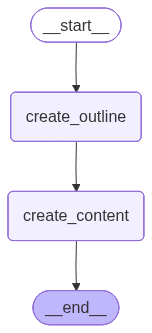

In [16]:
workflow

In [17]:
initial_state={'title':'AI in India'}
final_state=workflow.invoke(initial_state)
print(final_state)

{'title': 'AI in India', 'outline': 'Here\'s a detailed outline for a blog post on "AI in India," designed to be comprehensive, engaging, and informative for a broad audience.\n\n---\n\n## Blog Title Options:\n\n*   **India\'s AI Ascent: Unpacking the Revolution Shaping a Nation** (Chosen for outline)\n*   The Digital Awakening: How AI is Redefining India\'s Future\n*   Beyond the Hype: A Deep Dive into AI\'s Impact in India\n*   From Startups to Scale: Charting India\'s AI Journey\n*   India\'s Intelligence Boom: Why the World is Watching Its AI Evolution\n\n---\n\n## Detailed Blog Outline: India\'s AI Ascent: Unpacking the Revolution Shaping a Nation\n\n### **I. Introduction (Approx. 150-200 words)**\n\n*   **A. Catchy Hook:** Start with a compelling statistic or a vivid image of India\'s digital transformation and its scale. (e.g., "From bustling mega-cities to remote villages, India is undergoing a profound digital metamorphosis...")\n*   **B. Introduce AI\'s Role:** Briefly define

In [19]:
print(final_state['title'])

AI in India


In [20]:
print(final_state['outline'])

Here's a detailed outline for a blog post on "AI in India," designed to be comprehensive, engaging, and informative for a broad audience.

---

## Blog Title Options:

*   **India's AI Ascent: Unpacking the Revolution Shaping a Nation** (Chosen for outline)
*   The Digital Awakening: How AI is Redefining India's Future
*   Beyond the Hype: A Deep Dive into AI's Impact in India
*   From Startups to Scale: Charting India's AI Journey
*   India's Intelligence Boom: Why the World is Watching Its AI Evolution

---

## Detailed Blog Outline: India's AI Ascent: Unpacking the Revolution Shaping a Nation

### **I. Introduction (Approx. 150-200 words)**

*   **A. Catchy Hook:** Start with a compelling statistic or a vivid image of India's digital transformation and its scale. (e.g., "From bustling mega-cities to remote villages, India is undergoing a profound digital metamorphosis...")
*   **B. Introduce AI's Role:** Briefly define AI and immediately connect it to India's unique context – its va

In [21]:
print(final_state['content'])

## India's AI Ascent: Unpacking the Revolution Shaping a Nation

From bustling mega-cities teeming with digital natives to remote villages embracing smartphone connectivity, India is undergoing a profound digital metamorphosis. This transformation isn't just about adopting technology; it's about fundamentally reshaping how a nation of 1.4 billion people lives, works, and interacts. At the heart of this revolution lies Artificial Intelligence (AI) – a powerful suite of technologies enabling machines to learn, reason, and solve problems like humans. In India's unique context, AI isn't merely an upgrade; it's a strategic imperative, offering unprecedented opportunities to tackle complex challenges, drive inclusive growth, and unlock immense potential.

This blog post will delve into why India is rapidly emerging as a significant global player in AI, driven by unique demographic, technological, and governmental factors. We'll explore the current landscape, highlight key sectors being trans